<a href="https://colab.research.google.com/github/IsaacFigNewton/Multiplexed-Hypergraph-Visualizer/blob/main/Voronoi_Power_Diagram_View.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
"""
Nested labeled Voronoi *power diagram* (Laguerre diagram) with low cyclomatic complexity & LOC.

Design:
- PolygonOps: convex polygon clipping utilities
- HierarchyParser: parse a simple nested mapping
- DiagramConfig: all tunables in one place
- PowerDiagram: compute power cells within a convex domain polygon
- Plotter: orchestration + matplotlib drawing

Deps: numpy, matplotlib
"""

from __future__ import annotations

import math
from dataclasses import dataclass
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import matplotlib.pyplot as plt

Point = np.ndarray  # (2,)
Poly = List[Point]


# ------------------------ Config ------------------------

@dataclass(frozen=True)
class DiagramConfig:
    seed: int = 0
    radius: float = 1.0
    padding: float = 0.25
    top_jitter: float = 0.04
    child_jitter: float = 0.02
    child_radius_scale: float = 0.22
    figsize: Tuple[int, int] = (8, 8)
    top_weight_scale: Optional[float] = None
    child_weight_scale: Optional[float] = None


# ------------------------ Polygon ops ------------------------

class PolygonOps:
    @staticmethod
    def bbox(xmin: float, xmax: float, ymin: float, ymax: float) -> Poly:
        return [np.array([xmin, ymin], float), np.array([xmax, ymin], float),
                np.array([xmax, ymax], float), np.array([xmin, ymax], float)]

    @staticmethod
    def close(poly: Poly) -> np.ndarray:
        arr = np.asarray(poly, float)
        return np.vstack([arr, arr[0]])

    @staticmethod
    def clip_halfplane(poly: Poly, n: Point, c: float, eps: float = 1e-9) -> Poly:
        if not poly:
            return []

        def inside(x: Point) -> bool:
            return float(n @ x) <= c + eps

        def intersect(a: Point, b: Point) -> Point:
            ab = b - a
            denom = float(n @ ab)
            if abs(denom) < 1e-15:
                return a.copy()
            t = (c - float(n @ a)) / denom
            return a + np.clip(t, 0.0, 1.0) * ab

        out: Poly = []
        prev, prev_in = poly[-1], inside(poly[-1])
        for cur in poly:
            cur_in = inside(cur)
            if cur_in != prev_in:
                out.append(intersect(prev, cur))
            if cur_in:
                out.append(cur)
            prev, prev_in = cur, cur_in

        return PolygonOps._dedup(out)

    @staticmethod
    def _dedup(poly: Poly, tol: float = 1e-10) -> Poly:
        if not poly:
            return []
        out: Poly = [poly[0]]
        for p in poly[1:]:
            if np.linalg.norm(p - out[-1]) > tol:
                out.append(p)
        if len(out) > 1 and np.linalg.norm(out[0] - out[-1]) < tol:
            out.pop()
        return out


# ------------------------ Hierarchy parsing ------------------------

class HierarchyParser:
    """
    Accepts:
      {
        "A": {"weight": 0.8, "children": {"E": 0.3, "F": 1.2}},
        "B": 0.2,
        "C": 1.1
      }
    """

    @staticmethod
    def parse(tree: Dict[str, Any]) -> Tuple[Dict[str, float], Dict[str, Dict[str, float]]]:
        tops: Dict[str, float] = {}
        kids: Dict[str, Dict[str, float]] = {}
        for k, v in tree.items():
            if isinstance(v, dict) and ("children" in v or "weight" in v):
                tops[k] = float(v.get("weight", 0.0))
                ch = v.get("children") or {}
                if isinstance(ch, dict) and ch:
                    kids[k] = {ck: float(cw) for ck, cw in ch.items()}
            else:
                tops[k] = float(v)
        return tops, kids


# ------------------------ Power diagram ------------------------

@dataclass(frozen=True)
class Site:
    label: str
    p: Point
    w: float


class PowerDiagram:
    def __init__(self, ops: PolygonOps):
        self.ops = ops

    @staticmethod
    def auto_scale(weights: np.ndarray, length_scale: float) -> float:
        span = float(np.ptp(weights)) if len(weights) > 1 else 1.0
        return (length_scale * length_scale) / (span + 1e-9)

    def cell(self, s: Site, sites: List[Site], domain: Poly) -> Poly:
        poly = [np.array(v, float) for v in domain]
        for t in sites:
            if t is s:
                continue
            n, c = self._halfplane(s, t)
            poly = self.ops.clip_halfplane(poly, n, c)
            if not poly:
                break
        return poly

    @staticmethod
    def _halfplane(a: Site, b: Site) -> Tuple[Point, float]:
        # (pb-pa)·x <= 0.5*(||pb||^2 - ||pa||^2 + wa - wb)
        n = (b.p - a.p).astype(float)
        c = 0.5 * (float(b.p @ b.p) - float(a.p @ a.p) + a.w - b.w)
        return n, c


# ------------------------ Plotting orchestration ------------------------

class Plotter:
    def __init__(self, cfg: DiagramConfig):
        self.cfg = cfg
        self.rng = np.random.default_rng(cfg.seed)
        self.ops = PolygonOps()
        self.pd = PowerDiagram(self.ops)

    def plot(self, hierarchy: Dict[str, Any]) -> None:
        tops, kids = HierarchyParser.parse(hierarchy)
        top_sites, top_cells, domain, bbox = self._top_level(tops)
        fig, ax = plt.subplots(figsize=self.cfg.figsize)

        self._draw_cells(ax, top_sites, top_cells, alpha=0.25, lw=2)
        self._draw_children(ax, tops, kids, top_sites, top_cells)
        self._draw_sites(ax, tops, top_sites)

        xmin, xmax, ymin, ymax = bbox
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_title("Nested Voronoi Power Diagram (power cells with subcells)")
        ax.set_xticks([])
        ax.set_yticks([])
        plt.tight_layout()
        plt.show()

    # ---- build levels ----

    def _top_level(self, top_weights: Dict[str, float]) -> Tuple[List[Site], Dict[str, Poly], Poly, Tuple[float, float, float, float]]:
        labels = list(top_weights)
        w = np.array([top_weights[l] for l in labels], float)
        s = self.cfg.top_weight_scale or self.pd.auto_scale(w, self.cfg.radius)
        pts = self._circle_layout(labels, self.cfg.radius, self.cfg.top_jitter, center=np.zeros(2))
        sites = [Site(labels[i], pts[i], float(w[i] * s)) for i in range(len(labels))]

        r, p = self.cfg.radius, self.cfg.padding
        xmin, xmax, ymin, ymax = -r - p, r + p, -r - p, r + p
        domain = self.ops.bbox(xmin, xmax, ymin, ymax)
        cells = {s.label: self.pd.cell(s, sites, domain) for s in sites}
        return sites, cells, domain, (xmin, xmax, ymin, ymax)

    def _child_level(self, parent: Site, parent_poly: Poly, child_weights: Dict[str, float]) -> Tuple[List[Site], Dict[str, Poly]]:
        labels = list(child_weights)
        w = np.array([child_weights[l] for l in labels], float)
        scale_len = self.cfg.radius * self.cfg.child_radius_scale
        s = self.cfg.child_weight_scale or self.pd.auto_scale(w, scale_len)
        pts = self._circle_layout(labels, scale_len, self.cfg.child_jitter, center=parent.p)
        sites = [Site(labels[i], pts[i], float(w[i] * s)) for i in range(len(labels))]
        cells = {c.label: self.pd.cell(c, sites, parent_poly) for c in sites}
        return sites, cells

    # ---- layout ----

    def _circle_layout(self, labels: List[str], radius: float, jitter: float, center: Point) -> np.ndarray:
        n = len(labels)
        ang = np.linspace(0, 2 * math.pi, n, endpoint=False) if n > 1 else np.array([0.0])
        pts = np.c_[np.cos(ang), np.sin(ang)] * radius + center
        return (pts + self.rng.normal(0.0, jitter, size=pts.shape)).astype(float)

    # ---- drawing ----

    def _draw_cells(self, ax, sites: List[Site], cells: Dict[str, Poly], *, alpha: float, lw: float) -> None:
        for s in sites:
            poly = cells.get(s.label, [])
            if len(poly) < 3:
                continue
            ring = self.ops.close(poly)
            ax.fill(ring[:, 0], ring[:, 1], alpha=alpha)
            ax.plot(ring[:, 0], ring[:, 1], linewidth=lw)

    def _draw_sites(self, ax, weights: Dict[str, float], sites: List[Site]) -> None:
        for s in sites:
            ax.scatter([s.p[0]], [s.p[1]], s=30)
            ax.text(s.p[0] + 0.02, s.p[1] + 0.02, f"{s.label}\n(w={weights[s.label]:g})",
                    fontsize=10, ha="left", va="bottom")

    def _draw_children(
        self,
        ax,
        top_weights: Dict[str, float],
        kids: Dict[str, Dict[str, float]],
        top_sites: List[Site],
        top_cells: Dict[str, Poly],
    ) -> None:
        by_label = {s.label: s for s in top_sites}
        for parent_label, child_map in kids.items():
            parent_site = by_label.get(parent_label)
            parent_poly = top_cells.get(parent_label, [])
            if not parent_site or len(parent_poly) < 3 or not child_map:
                continue
            child_sites, child_cells = self._child_level(parent_site, parent_poly, child_map)
            self._draw_cells(ax, child_sites, child_cells, alpha=0.35, lw=1.2)
            for cs in child_sites:
                ax.scatter([cs.p[0]], [cs.p[1]], s=16)
                ax.text(cs.p[0] + 0.015, cs.p[1] + 0.015, cs.label, fontsize=9)

# Tests

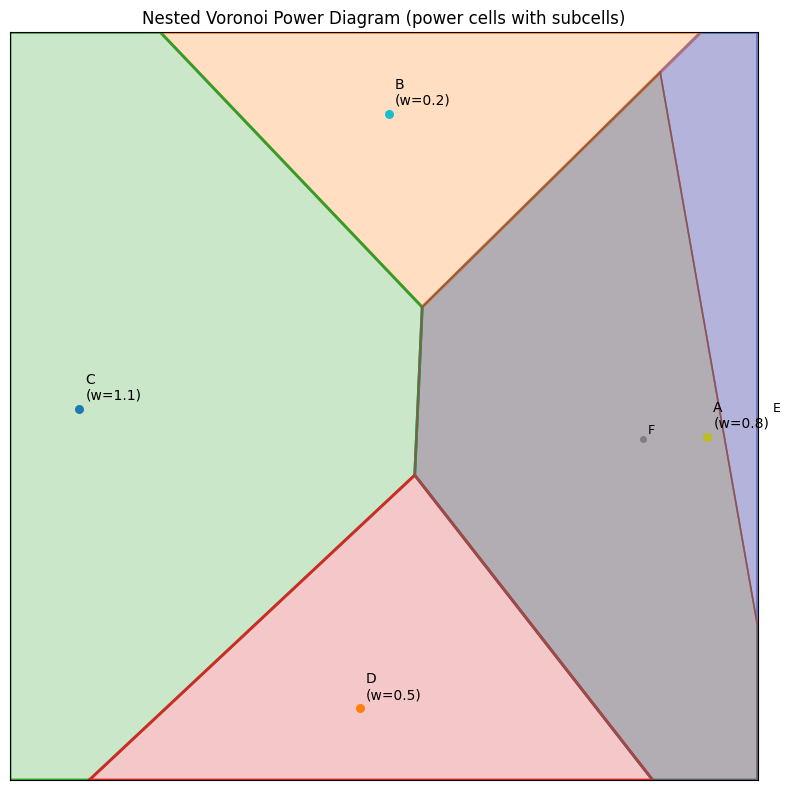

In [8]:
hierarchy = {
    "A": {"weight": 0.8, "children": {"E": 0.3, "F": 1.2}},
    "B": 0.2,
    "C": 1.1,
    "D": 0.5,
}
Plotter(DiagramConfig(seed=3)).plot(hierarchy)